# Time Series Forecasting - A Showcase Example

The objective of this project is to make time series forecasting on weather data. The [weather time series dataset](https://www.bgc-jena.mpg.de/wetter/) recorded by [the Max Planck Institute for Biogeochemistry](https://www.bgc-jena.mpg.de/). The section of the dataset used for this homework was prepared by François Chollet for his book [Deep Learning with Python](https://www.manning.com/books/deep-learning-with-python).

The dataset consists of 19 features measured every hour for 8 years (from 2009 to 2016 included). We will try to predict the temperature `T (degC)` for the next 48 hours using previous data (including the temperature). We choose a window input of one week.

Reusable pipeline code (windowing, baselines, scaling, models, training, evaluation) lives in [`src/`](src/) and is unit tested in [`tests/`](tests/); this notebook is the analysis/report layer that imports from it.

In [1]:
import os

# LightGBM and PyTorch each ship their own OpenMP runtime; loading both in one
# process can deadlock on macOS unless we cap threads and allow the duplicate
# runtime. Must be set before either library is imported.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

import random
from functools import partial
from math import ceil

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from torch.utils.data import DataLoader, TensorDataset

from src.baselines import last_step_baseline, mean_baseline, repeat_baseline
from src.evaluation import evaluate_model, mae_by_horizon
from src.models import LSTMForecaster
from src.scaling import Standardizer
from src.training import train_lstm
from src.windowing import extract_windows, have_regular_time_steps
from visualization import plot_window

# fix every source of randomness so the notebook is reproducible end to end
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)  # see the OpenMP note above

## I ☁️ Load the weather dataset

The dataset is a csv filed called `weather_dataset.csv` and the index column correspond to the `"Date Time"`.

In [2]:
# load weather dataset with the date as index
weather_dataset = pd.read_csv('data/weather_dataset.csv', index_col="Date Time")

# format date index
weather_dataset.index = pd.to_datetime(weather_dataset.index, format="%d.%m.%Y %H:%M:%S")

# show the first 5 time steps
weather_dataset.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,,,,,,,,,,,,,,,
2009-01-01 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,-0.204862,-0.046168,-0.614587,-0.138503,0.258819,0.965926,0.010049,0.999950
2009-01-01 02:00:00,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,-0.245971,-0.044701,-0.619848,-0.112645,0.500000,0.866025,0.010766,0.999942
2009-01-01 03:00:00,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,-0.175527,0.039879,-0.614344,0.139576,0.707107,0.707107,0.011483,0.999934
2009-01-01 04:00:00,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,-0.050000,-0.086603,-0.190000,-0.329090,0.866025,0.500000,0.012199,0.999926
2009-01-01 05:00:00,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,-0.368202,0.156292,-0.810044,0.343843,0.965926,0.258819,0.012916,0.999917


## II 🔎 Explore the dataset

In [3]:
print(f"The dataset has {weather_dataset.shape[0]} samples and {weather_dataset.shape[1]} features")

The dataset has 70091 samples and 19 features


### II.1 ↔️ Correlations

Let's explore the correlation between features. We might be able to reduce the number of features and ease data exploration and model training.

All features with a correlation strictly above 0.95 will be remove.

This correlation matrix is computed on the *full* dataset purely for exploration. The actual decision of which columns to drop is revalidated on the train split only in section III.1, so it can't leak information from the validation/test years — see the note there.

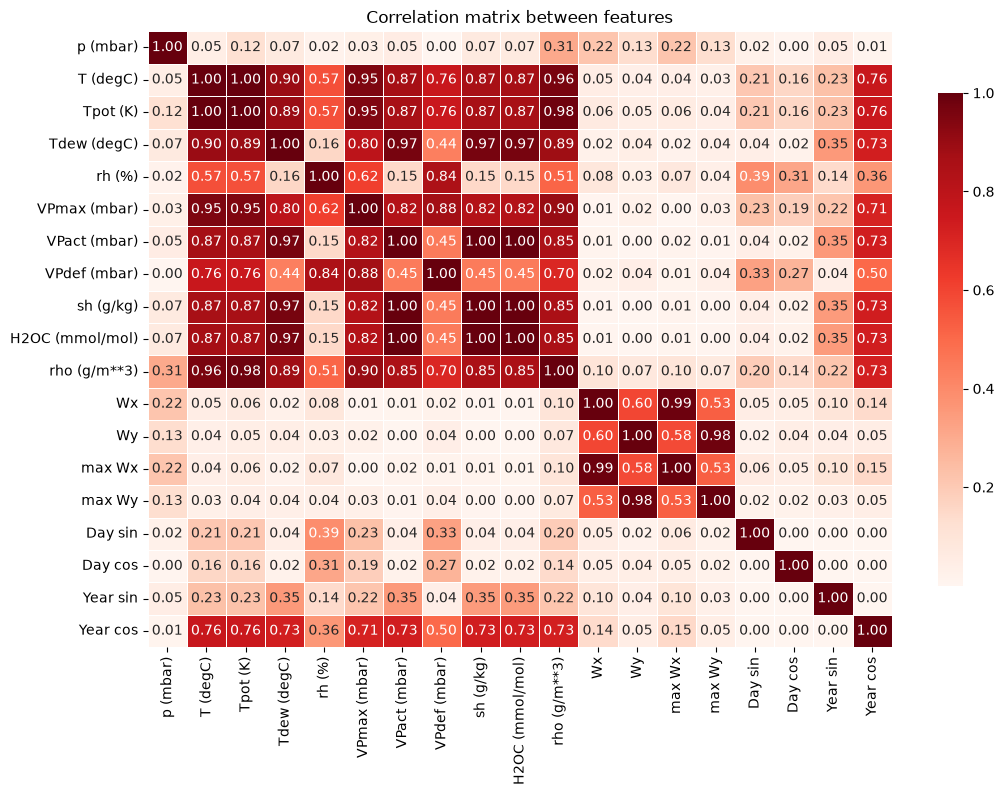

The removed features are: ['Tpot (K)', 'VPmax (mbar)', 'VPact (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'max Wx', 'max Wy']
The remaining features are: Index(['p (mbar)', 'T (degC)', 'Tdew (degC)', 'rh (%)', 'VPdef (mbar)', 'Wx',
       'Wy', 'Day sin', 'Day cos', 'Year sin', 'Year cos'],
      dtype='str')
Hence the shape of the reduced dataset is: (70091, 11)


In [4]:
# compute correlations
features_correlation_matrix = weather_dataset.corr().abs()

# visualize correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(features_correlation_matrix, cmap='Reds', annot=True, fmt=".2f", cbar_kws={"shrink": 0.8}, linewidths=0.5)
plt.title('Correlation matrix between features')
plt.show()

# set the diagonal and lower triangle to zero (we only want to remove one element of pairs)
upper = features_correlation_matrix.where(~np.tril(np.ones(features_correlation_matrix.shape)).astype(bool))

# find index/column names of pairs with correlation greater than 0.95
features_to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

# drop highly correlated columns
reduced_weather_dataset = weather_dataset.drop(columns=features_to_drop)

print(f"The removed features are: {features_to_drop}")
print(f"The remaining features are: {reduced_weather_dataset.columns}")
print(f"Hence the shape of the reduced dataset is: {reduced_weather_dataset.shape}")

<div class="alert alert-info">

We can see an interesting correlation between `Year cos` and the temperature `T (degC)` which suggest an important yearly seasonality.

### II.2 ❓ Data types and missing values

In [5]:
reduced_weather_dataset.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 70091 entries, 2009-01-01 01:00:00 to 2016-12-31 23:10:00
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   p (mbar)      70091 non-null  float64
 1   T (degC)      70091 non-null  float64
 2   Tdew (degC)   70091 non-null  float64
 3   rh (%)        70091 non-null  float64
 4   VPdef (mbar)  70091 non-null  float64
 5   Wx            70091 non-null  float64
 6   Wy            70091 non-null  float64
 7   Day sin       70091 non-null  float64
 8   Day cos       70091 non-null  float64
 9   Year sin      70091 non-null  float64
 10  Year cos      70091 non-null  float64
dtypes: float64(11)
memory usage: 6.4 MB


<div class="alert alert-info">

The dataset do not have missing values and values are all in `float64`.

### II.3 ⏲️ Time steps study

With time series, several things are important to test as they have a huge impact on how we sould treat the dataset.

Here, we will check if time steps are:
- correctly ordered
- spaced equally
- not duplicated

In [6]:
# compute the length of the time steps
indexes = pd.Series(reduced_weather_dataset.index)
all_time_steps_lengths = indexes - indexes.shift()
time_steps_lengths_count = all_time_steps_lengths.value_counts()

print(time_steps_lengths_count)

Date Time
0 days 01:00:00      70083
0 days 01:10:00          2
0 days 01:20:00          1
-1 days +01:00:00        1
-2 days +18:30:00        1
0 days 16:50:00          1
3 days 03:10:00          1
Name: count, dtype: int64


<div class="alert alert-info">

We can see here that there are negative time steps duration. Therefore, the dataset is not sorted by date. Let's sort it and compute this time step length again.

In [7]:
# sort dataset
sorted_dataset = reduced_weather_dataset.sort_index()

# compute the length of the time steps
indexes = pd.Series(sorted_dataset.index)
all_time_steps_lengths = indexes - indexes.shift()
time_steps_lengths_count = all_time_steps_lengths.value_counts()

print(time_steps_lengths_count)

Date Time
0 days 01:00:00    70000
0 days 00:30:00       61
0 days 00:00:00       24
0 days 01:10:00        2
0 days 01:20:00        1
0 days 16:50:00        1
3 days 03:10:00        1
Name: count, dtype: int64


<div class="alert alert-info">

Now we have only positive time steps, but three problems appear:
- There are 24 duplicates that we will drop in the following cell.
- There are time steps close to one hour or smaller than one hour. We will take the mean for each hour and hope to reduce this problems.
- There are gaps that cannot be filled. We will leave them and remove windows that possess such gaps after windowing. `have_regular_time_steps` (in `src/windowing.py`) implements that check.

In [8]:
# drop duplicates
clean_dataset = sorted_dataset.drop_duplicates()

# resample to one hour by taking the mean for each hour
clean_dataset = clean_dataset.resample('h').mean()

# remove time steps that were filled with NaN values
clean_dataset = clean_dataset.dropna()

# confirm we solved part of the problems
indexes = pd.Series(clean_dataset.index)
all_time_steps_lengths = indexes - indexes.shift()
time_steps_lengths_count = all_time_steps_lengths.value_counts()

print(time_steps_lengths_count)

Date Time
0 days 01:00:00    70034
0 days 17:00:00        1
3 days 03:00:00        1
Name: count, dtype: int64


In [9]:
# quickly test the have_regular_time_steps function (imported from src.windowing)
assert not have_regular_time_steps(clean_dataset)  # the whole dataset have gaps
assert have_regular_time_steps(clean_dataset.iloc[:(31 * 24)])  # the first month do not have gaps

### II.4 📶 Dataset distribution

We will:
- Show dataset statistics.
- Visualize features distribution.

In [10]:
clean_dataset.describe()

,p (mbar),T (degC),Tdew (degC),rh (%),VPdef (mbar),Wx,Wy,Day sin,Day cos,Year sin,Year cos
count,70037.000000,70037.000000,70037.000000,70037.000000,70037.000000,70037.000000,70037.000000,7.003700e+04,7.003700e+04,70037.000000,70037.000000
mean,989.214128,9.442833,4.954083,76.029967,4.036448,-0.626668,-0.406815,-2.674072e-05,-7.375082e-05,0.001191,-0.000417
std,8.361298,8.421184,6.730542,16.459548,4.893142,1.985749,1.552214,7.071103e-01,7.071121e-01,0.706796,0.707427
min,913.600000,-22.760000,-24.800000,13.880000,0.000000,-11.305514,-8.274385,-1.000000e+00,-1.000000e+00,-1.000000,-1.000000
25%,984.200000,3.340000,0.240000,65.240000,0.870000,-1.469633,-1.364738,-7.071068e-01,-7.071068e-01,-0.704896,-0.707815
50%,989.570000,9.400000,5.210000,79.300000,2.180000,-0.633055,-0.293467,2.697701e-14,1.072788e-14,0.002071,-0.001184
75%,994.730000,15.470000,10.070000,89.500000,5.290000,0.299841,0.450039,7.071068e-01,7.071068e-01,0.707789,0.707837
max,1015.290000,37.280000,23.060000,100.000000,46.010000,8.244699,7.733831,1.000000e+00,1.000000e+00,1.000000,1.000000


<div class="alert alert-info">

The dataset have a large diversity of values, normalization will be required to obtain better results.

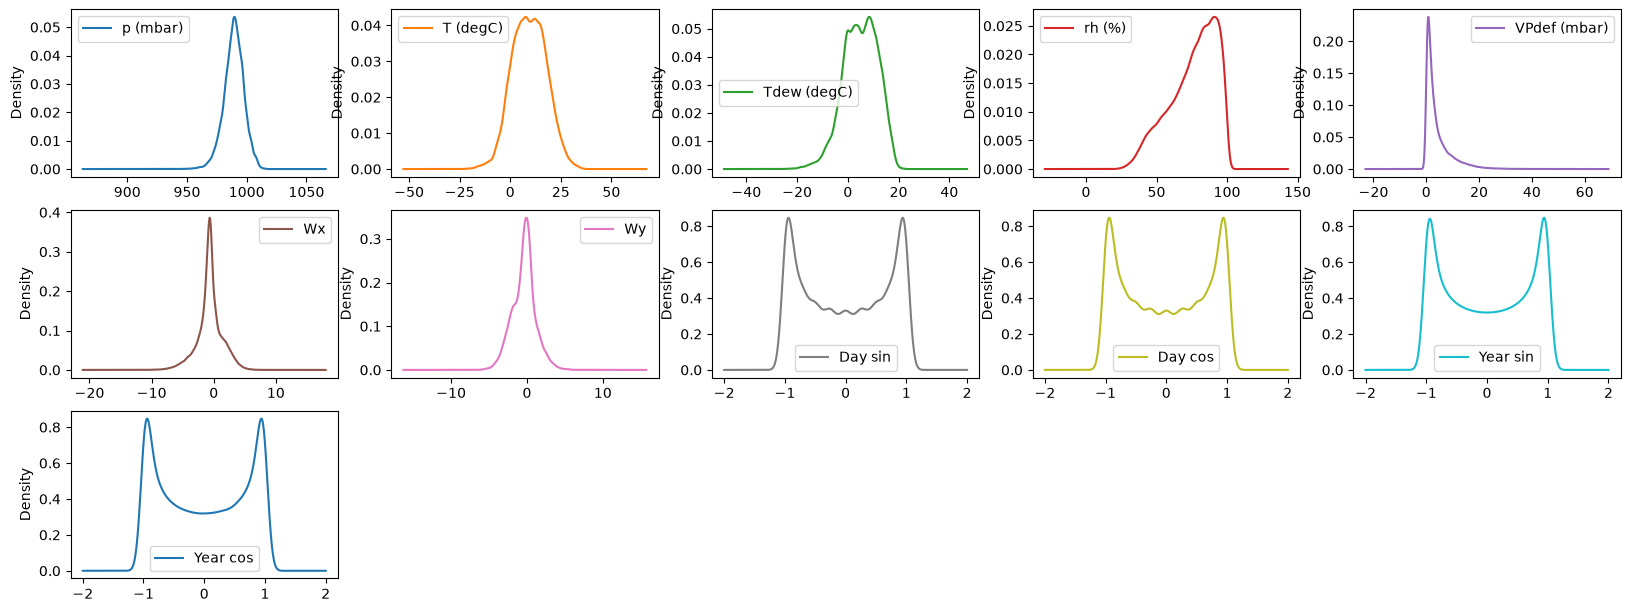

In [11]:
# show features distributions
clean_dataset.plot(kind="density", subplots=True, layout=(4, 5), sharex=False, figsize=(20,10))
plt.show()

<div class="alert alert-info">

We can see that:
- The temperature (T (degC)) is close to a normal distribution centered on 5 or 10 celsius degrees.
- rh% have a high density close to 100 but is limited to 100.
- Wind related features (Wx, Wy) are centered on zero.
- Time related features (Day sin, Day cos, Year sin, Year cos) are between -1 and 1 with spikes on -1 and 1. This is coherent with a cosinus or sinus function.

### II.5 📈 Features evolution along time.

Let's see how our features evolve and if we can detect seasonality. We begin by showing the whole dataset (*i.e.* the 8 years).

/var/folders/qw/hl3htbzn48d63s9v3rgj11v00000gn/T/ipykernel_2109/1758000556.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[0].set_xticklabels([str(year) for year in range(2009, 2017)])
/var/folders/qw/hl3htbzn48d63s9v3rgj11v00000gn/T/ipykernel_2109/1758000556.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[0].set_xticklabels([str(year) for year in range(2009, 2017)])
/var/folders/qw/hl3htbzn48d63s9v3rgj11v00000gn/T/ipykernel_2109/1758000556.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[0].set_xticklabels([str(year) for year in range(2009, 2017)])
/var/folders/qw/hl3htbzn48d63s9v3rgj11v00000gn/T/ipykernel_2109/

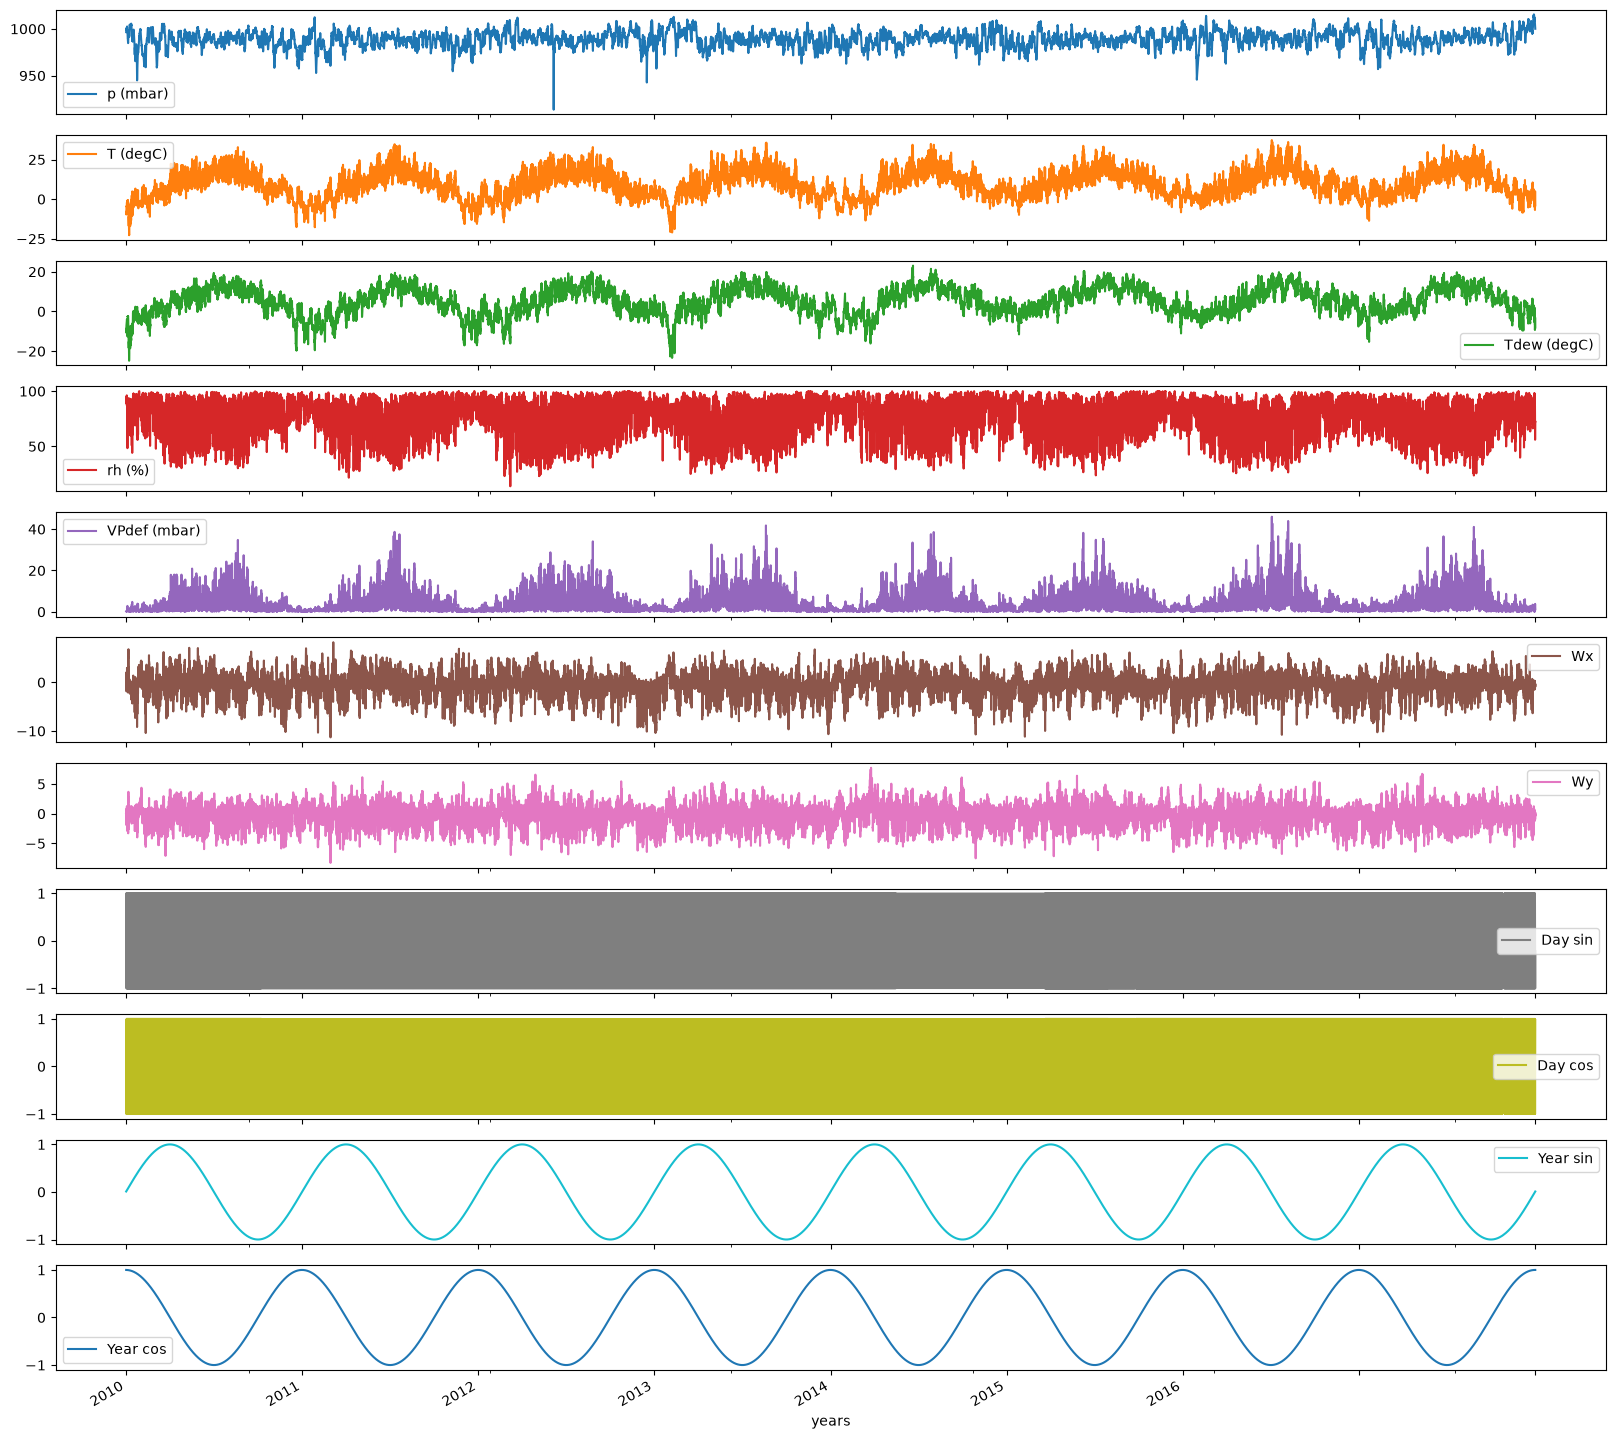

In [12]:
# show features evolution over time
axes = clean_dataset.plot(subplots=True, figsize=(20,20), layout=(11, 1),
                          sharex=True, sharey=False, xlabel="years")

# set xticks labels
for ax in axes:
    ax[0].set_xticklabels([str(year) for year in range(2009, 2017)])
plt.show()

<div class="alert alert-info">

As we could expect from weather data, there seem to be a yearly seasonality. We will verify it through an FFT afterward, but for now let's zoom on a one month period. We expect a daily seasonality.

/var/folders/qw/hl3htbzn48d63s9v3rgj11v00000gn/T/ipykernel_2109/2144189016.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[0].set_xticklabels([str(year) for year in range(1, 32)])
/var/folders/qw/hl3htbzn48d63s9v3rgj11v00000gn/T/ipykernel_2109/2144189016.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[0].set_xticklabels([str(year) for year in range(1, 32)])
/var/folders/qw/hl3htbzn48d63s9v3rgj11v00000gn/T/ipykernel_2109/2144189016.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[0].set_xticklabels([str(year) for year in range(1, 32)])
/var/folders/qw/hl3htbzn48d63s9v3rgj11v00000gn/T/ipykernel_2109/2144189016.py:8

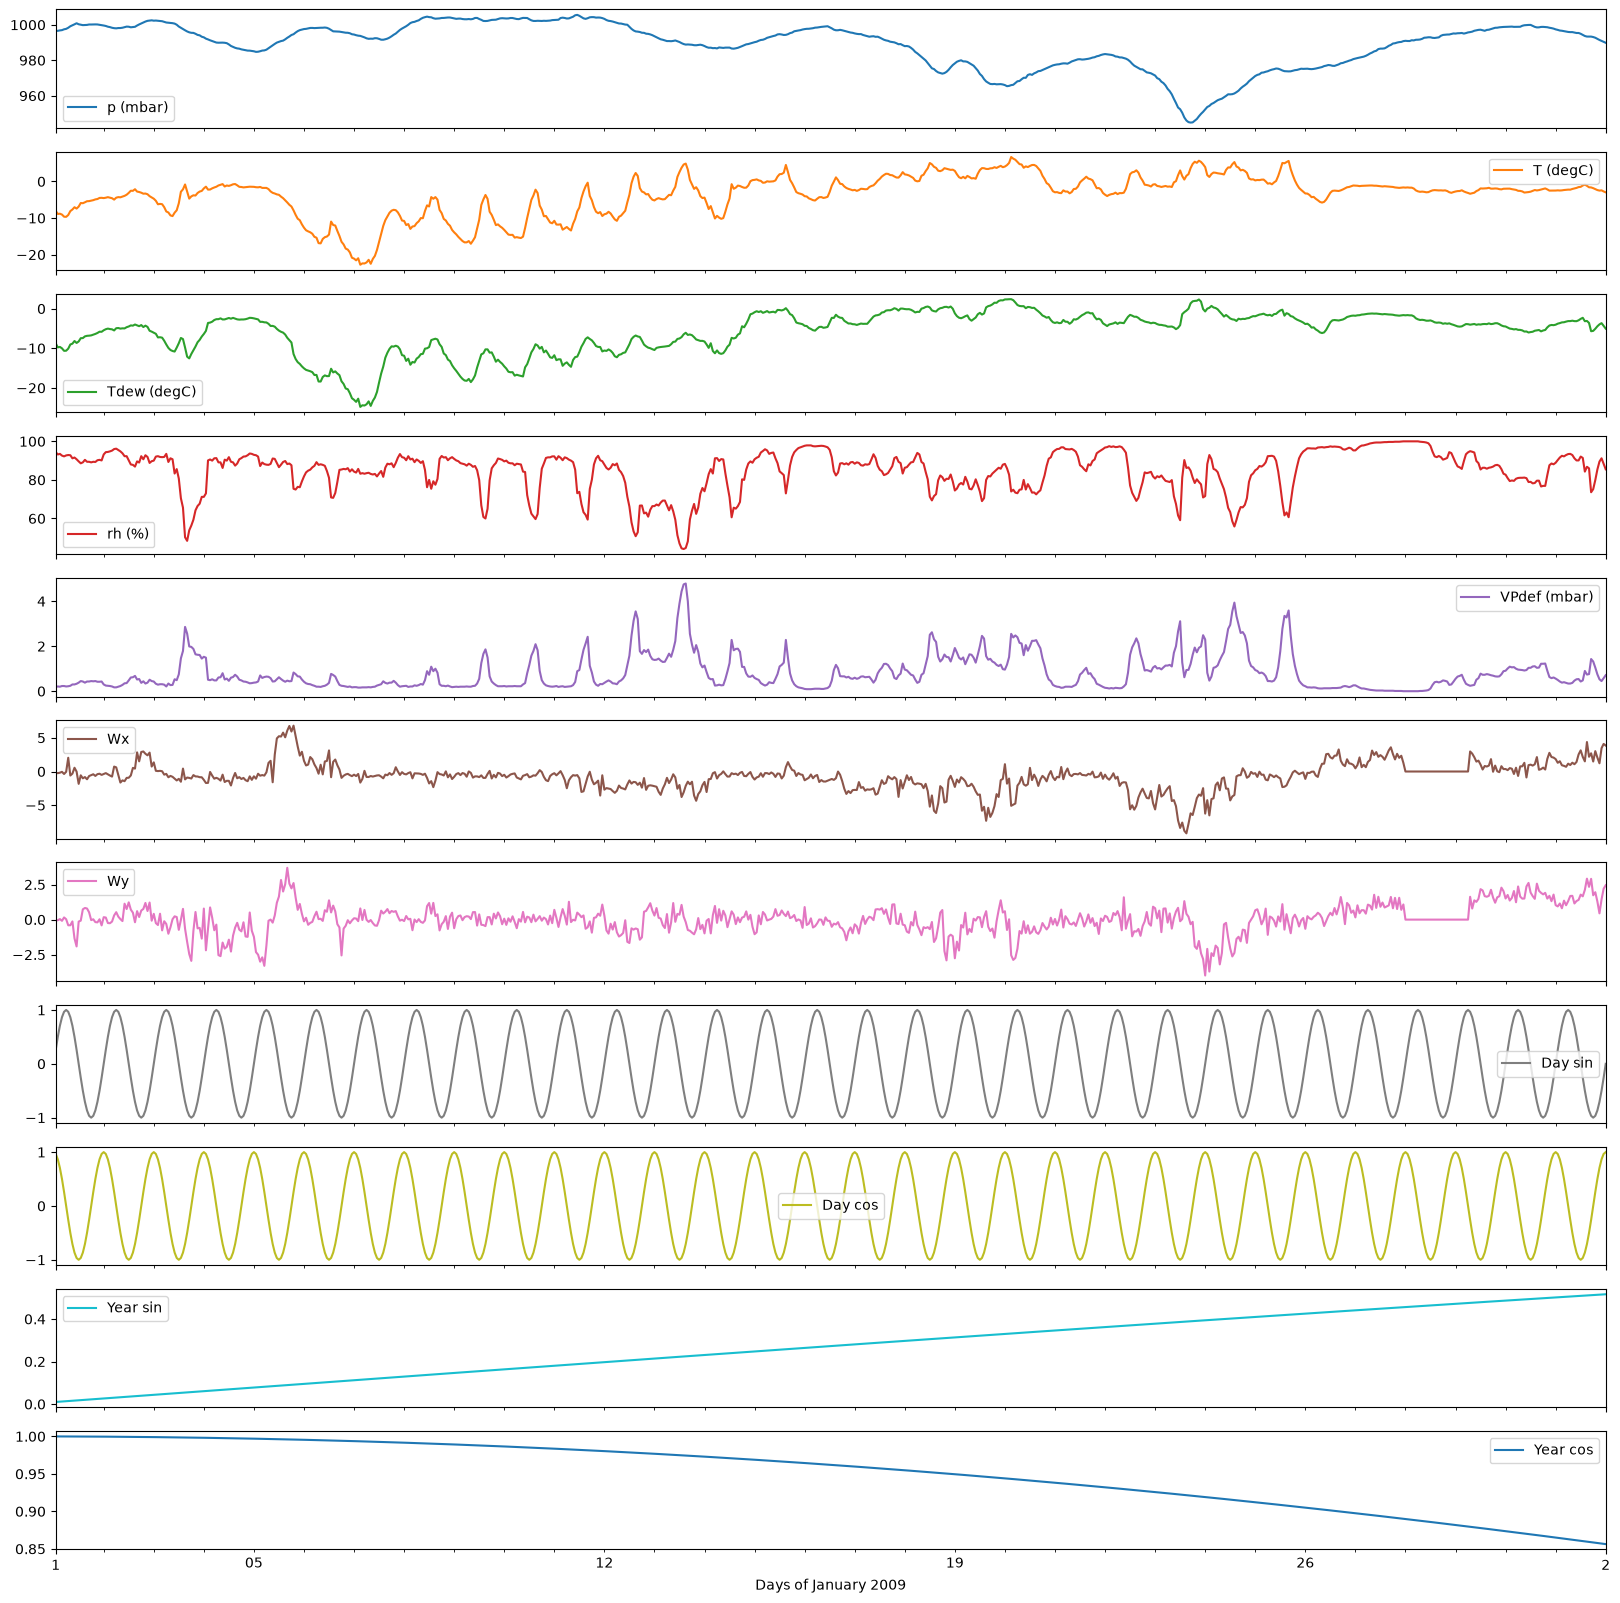

In [13]:
# show features evolution over time
axes = clean_dataset.iloc[:(31 * 24)].plot(subplots=True, figsize=(20,20), layout=(11, 1),
                                           sharex=True, sharey=False,
                                           xlabel="Days of January 2009")

# set xticks labels
for ax in axes:
    ax[0].set_xticklabels([str(year) for year in range(1, 32)])
plt.show()

<div class="alert alert-info">

The daily seasonality also appears, but not on all features, futhermore, it is less clear. However, we only looked at one month, let's study the dataset in the frequency domain.

### II.6 📊 Frequency analysis

To analyze the dataset in the frequency domain, we use the Fourier transformation in its optimized version fft.

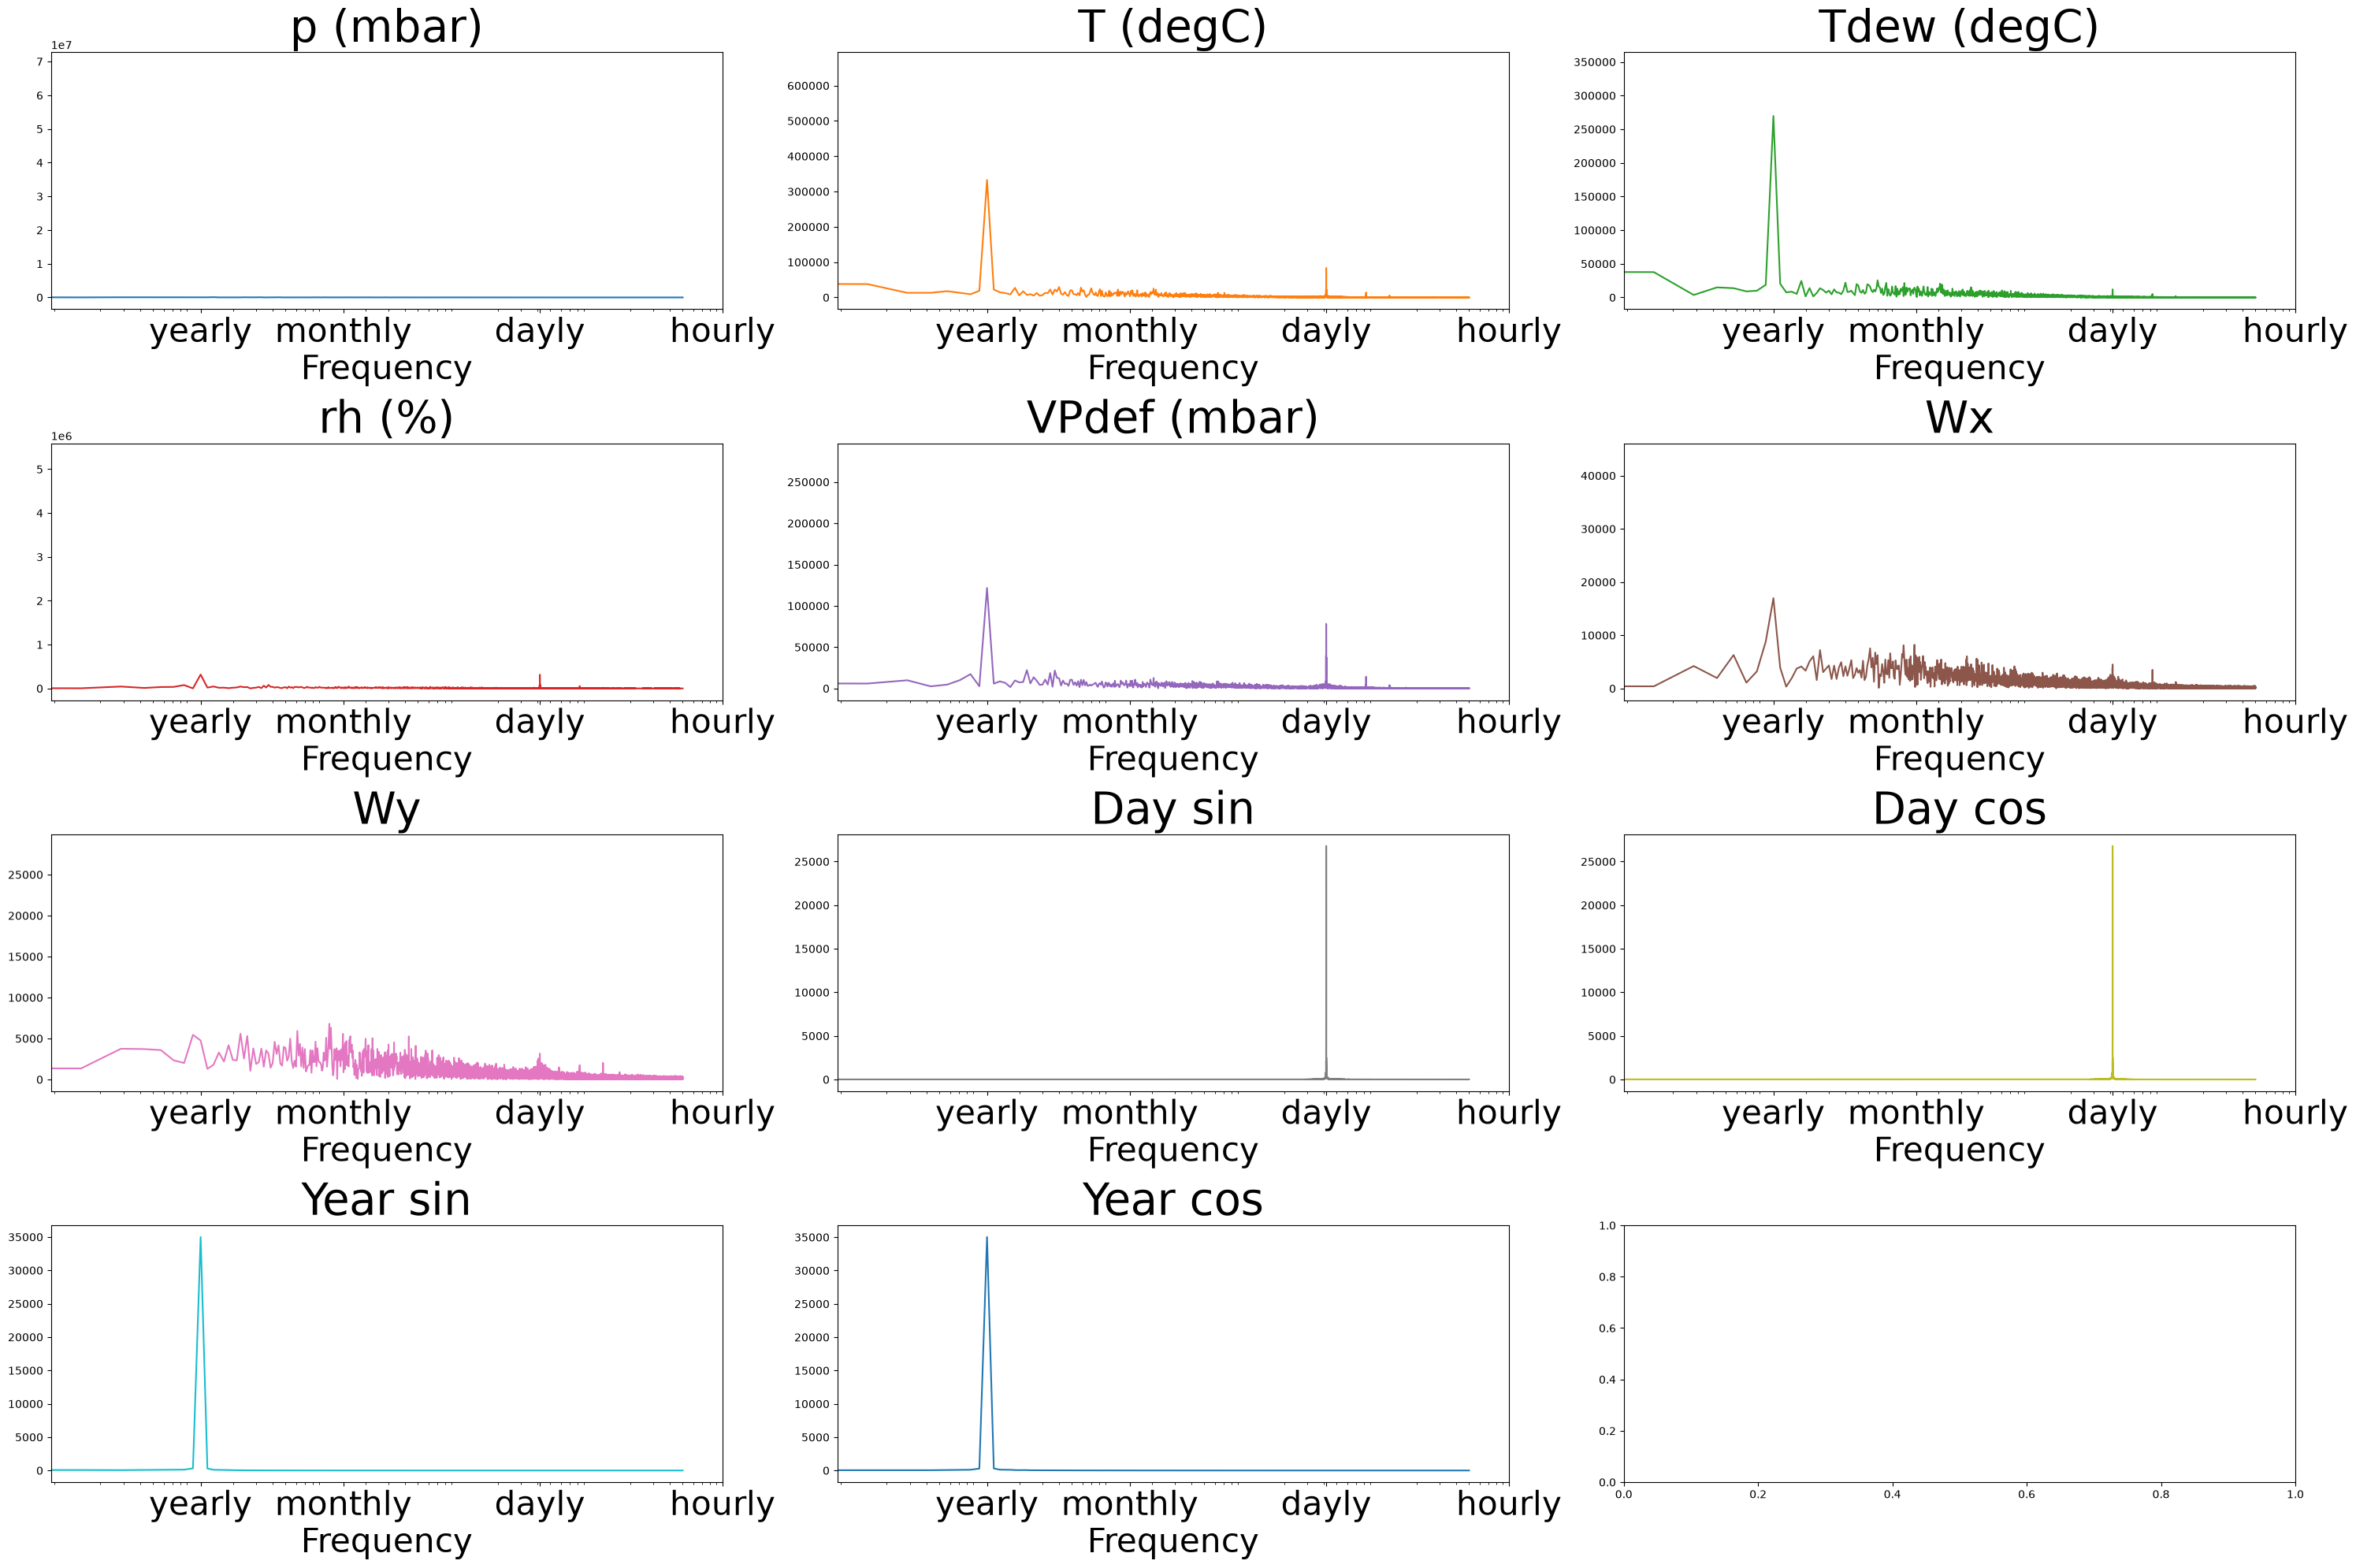

In [14]:
nb_cols = 3
cmap = plt.get_cmap('tab10')
fig, axes = plt.subplots(nrows=ceil(clean_dataset.shape[1] / nb_cols),
                         ncols=nb_cols,
                         figsize=(30,20))

# compute the frequencies (x axis of the plot)
sampling_rate = 1  # 1 sample per hour
nb_timesteps = clean_dataset.shape[0]
freq = np.fft.fftfreq(nb_timesteps, d=1/sampling_rate)
freq = freq[:nb_timesteps//2]

# iterate on each feature
for i, feature in enumerate(clean_dataset.columns):
    ax = axes[i//nb_cols, i%nb_cols]

    # fft for the given feature
    fft_values = np.fft.fft(clean_dataset[feature])

    # keep only positive frequencies
    fft_values = np.abs(fft_values)[:nb_timesteps//2]

    # plot fft
    ax.plot(freq, fft_values, label=feature, color=cmap(i % 10))

    ax.set_title(feature, fontsize=40)

    # set x-axis to log scale and set x-axis label for interpretable frequency
    ax.set_xscale("log")
    ax.set_xlabel("Frequency", fontsize=30)
    ax.set_xticks([1 / (24 * 365.2425), 1 / (24 * (365.2425 / 12)), 1 / 24, 1])
    ax.set_xticklabels(["yearly", "monthly", "dayly", "hourly"], fontsize=30)
plt.tight_layout()
plt.show()

<div class="alert alert-info">

We have now proved our daily and yearly seasonality. At least for the temperature, for other features there might not be one of the two seasonality.

## III 🛠️ Dataset Processing

Set features id to easily manipulate them.

In [15]:
# set variables to easily go from id to feature names and vice-versa.
# Note: we derive this from `clean_dataset` (post correlation-drop), not the raw
# `weather_dataset`, so `target_feature_id` stays a valid index into every array
# we window/normalize downstream even if a feature *before* the target gets dropped.
features_id2names = clean_dataset.columns
features_names2id = {name: id for id, name in enumerate(features_id2names)}

# stock target feature name and id
target_feature = "T (degC)"
target_feature_id = features_names2id[target_feature]

### III.1 ✂️ Split dataset between train val test

In the case of time series forecasting, we often aim for our final model to work for future data. In ou case, we expect the model to work well on weather forecast on years from 2017 and onward. To evaluate such capacity, the test set will consist of the three last years of the dataset (2015 and 2016). Therefore, the validation set will consist of the years 2013 and 2014.

The dataset consist of 8 years, 4 for training, 2 for validation, and 2 for testing.

In [16]:
# split between train, validation and test set (4/8 train, 2/8 validation, 2/8 test)
train_raw = clean_dataset[clean_dataset.index.year.isin([2009,2010,2011,2012])]
val_raw = clean_dataset[clean_dataset.index.year.isin([2013, 2014])]
test_raw = clean_dataset[clean_dataset.index.year.isin([2015, 2016])]

# show the resulting shapes
print(f"Train dataset shape: {train_raw.shape}")
print(f"Val dataset shape: {val_raw.shape}")
print(f"Test dataset shape: {test_raw.shape}")

Train dataset shape: (35063, 11)
Val dataset shape: (17504, 11)
Test dataset shape: (17470, 11)


#### Sanity check: does the correlation-based feature drop leak from val/test?

Section II.1 computed `features_to_drop` on the *full* 8-year dataset, before any split existed. Strictly speaking, decisions that shape what a model is allowed to see should be derived from the train split only. We check here whether it actually mattered for this dataset: we recompute the same >0.95 correlation rule using only the train years (2009-2012) and compare the resulting drop list.

In [17]:
# recompute the correlation-based feature selection using ONLY the train years,
# on the same cleaning pipeline (sort, dedupe, hourly resample, dropna) applied to
# the untouched (all 19 features) dataset restricted to the train period.
train_years = [2009, 2010, 2011, 2012]
train_only_all_features = (
    weather_dataset
    .sort_index()
    .drop_duplicates()
    .resample('h').mean()
    .dropna()
)
train_only_all_features = train_only_all_features[train_only_all_features.index.year.isin(train_years)]

train_only_corr = train_only_all_features.corr().abs()
train_only_upper = train_only_corr.where(~np.tril(np.ones(train_only_corr.shape)).astype(bool))
train_only_features_to_drop = [c for c in train_only_upper.columns if any(train_only_upper[c] > 0.95)]

print(f"Dropped using the full 8-year dataset: {sorted(features_to_drop)}")
print(f"Dropped using the train split only:    {sorted(train_only_features_to_drop)}")

leak_changed_the_outcome = sorted(features_to_drop) != sorted(train_only_features_to_drop)
print(f"Feature selection would have changed if fit on train only: {leak_changed_the_outcome}")

Dropped using the full 8-year dataset: ['H2OC (mmol/mol)', 'Tpot (K)', 'VPact (mbar)', 'VPmax (mbar)', 'max Wx', 'max Wy', 'rho (g/m**3)', 'sh (g/kg)']
Dropped using the train split only:    ['H2OC (mmol/mol)', 'Tpot (K)', 'VPact (mbar)', 'max Wx', 'max Wy', 'rho (g/m**3)', 'sh (g/kg)']
Feature selection would have changed if fit on train only: True


<div class="alert alert-info">

The lists are **not** identical: `VPmax (mbar)` is dropped when the threshold is computed on the full dataset, but survives when computed on the train split only. This is a real (if narrow) instance of the leak we were checking for, and it's worth being precise about *why*: `corr(VPmax, T) = 0.9511` on the full 8-year dataset, just above the 0.95 cutoff, versus `0.9479` on the train years only, just below it. It's a threshold effect, not a different underlying relationship — the correlation itself barely moves, but a hard cutoff turns that tiny move into a binary "drop it or don't."

In practice the consequence is small: `VPmax (mbar)` is itself redundant with `T (degC)`, `Tpot (K)`-correlated quantities, and `VPdef (mbar)`, all of which remain in the reduced dataset either way, so no genuinely new information falls out of the model. But the mechanism is exactly the kind of leakage this check exists to catch, and on a less redundant feature set the same threshold-boundary effect could quietly change what a model is allowed to see. We keep the original full-dataset selection for the rest of the notebook (re-deriving every downstream cell around a train-only feature list is out of scope for a single-feature, threshold-boundary difference), but the honest fix — for a dataset where this mattered more — would be to fit `features_to_drop` on `train_raw` and slice `val_raw`/`test_raw` to the same columns, not the other way around.

### III.2 📶 Normalize dataset

We previously detected varying features order of magnitude, let's normalize the data. `Standardizer` (in `src/scaling.py`) fits its mean/std/min/max on the train split only, and is reused everywhere downstream (normalization, rescaling predictions back to degrees, and clipping) so no val/test statistic ever leaks into training.

In [18]:
scaler = Standardizer(target_feature=target_feature).fit(train_raw)

# apply normalization with the train set statistics
train_normalized = scaler.transform(train_raw)
val_normalized = scaler.transform(val_raw)
test_normalized = scaler.transform(test_raw)

### III.3 🗂️ Window dataset

In the current dataset, the samples correspond to time steps, however, we need samples and labels to correspond to windows of several hours/days. Labels do not need to have the same size as samples, they could be multivariate or single variate.

In our case we will make input windows of 4 days, output windows of 2 days, and a shift of 5 hours between each global window (input and output).

In [19]:
# set windows parameters
samples_window_size = 24 * 4  # four days
window_step = 5  # small shift that does not divide 24
labels_window_size = 24 * 2  # two days

# extract windows (extract_windows imported from src.windowing)
train_sample_windows, train_label_windows = extract_windows(
    train_normalized, samples_window_size, labels_window_size, window_step, target_feature_id
)
val_sample_windows, val_label_windows = extract_windows(
    val_normalized, samples_window_size, labels_window_size, window_step, target_feature_id
)
test_sample_windows, test_label_windows = extract_windows(
    test_normalized, samples_window_size, labels_window_size, window_step, target_feature_id
)

# verification of the shape
print(f"train_sample_windows.shape: {train_sample_windows.shape}, train_label_windows.shape: {train_label_windows.shape}")
print(f"val_sample_windows.shape: {val_sample_windows.shape}, val_label_windows.shape: {val_label_windows.shape}")
print(f"test_sample_windows.shape: {test_sample_windows.shape}, test_label_windows.shape: {test_label_windows.shape}")

train_sample_windows.shape: (6984, 96, 11), train_label_windows.shape: (6984, 48)
val_sample_windows.shape: (3444, 96, 11), val_label_windows.shape: (3444, 48)
test_sample_windows.shape: (3437, 96, 11), test_label_windows.shape: (3437, 48)


We have extracted windows, the shapes seems coherent, but we should do some visualizations to be sure.

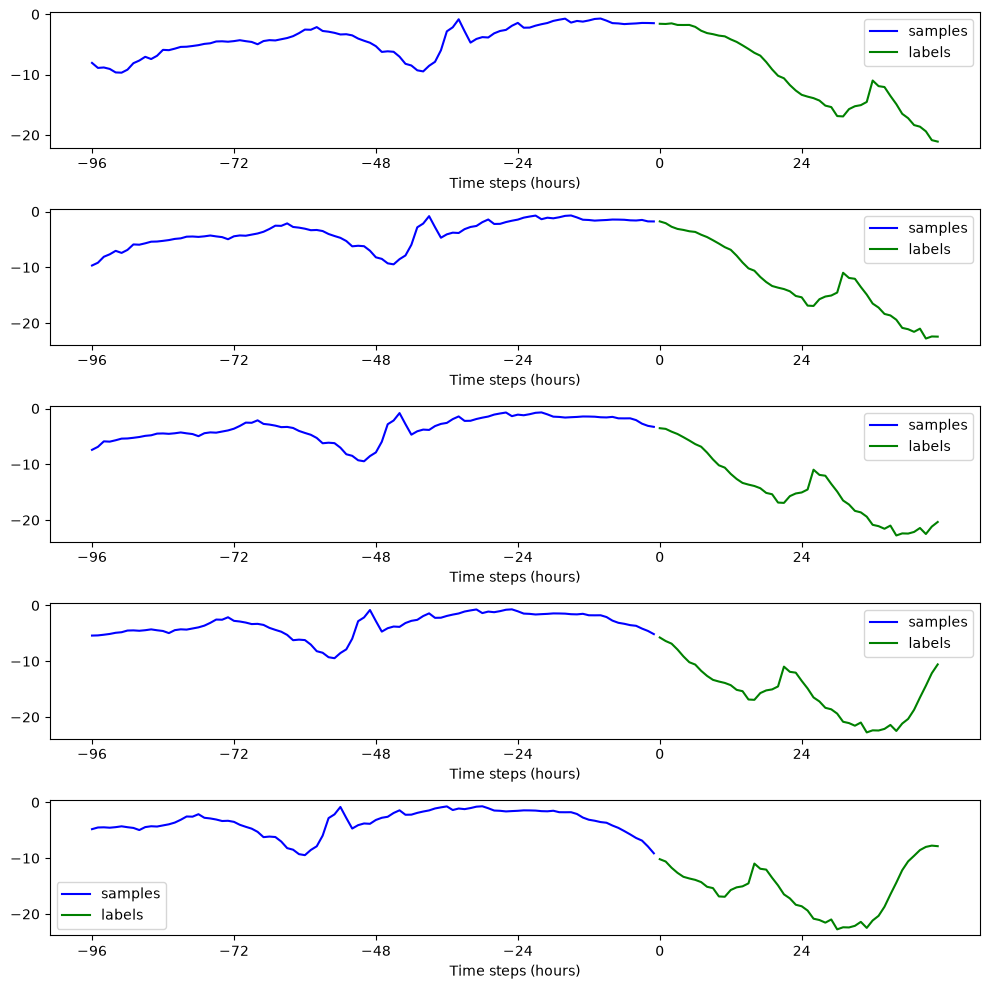

In [20]:
nb_samples_to_plot = 5

samples = scaler.inverse_transform_target(train_sample_windows[:, :, target_feature_id])
labels = scaler.inverse_transform_target(train_label_windows)

plot_window(samples, labels, nb_samples_to_plot=nb_samples_to_plot)

<div class="alert alert-info">

The curves correspond to what we expected, there is a 5 slide between each window, the input is a one week window while the target is a two days window.

## IV 🚀 Training models

We will now train our models. We start with baselines, then try three families of models:
- Machine learning: linear regression
- Machine learning: gradient boosted trees (LightGBM)
- Deep learning: LSTM

But before, let's define metrics and baselines.

### IV.1 🔬 Metric for model evaluation

We will use the mean absolute error (MAE) as our metric, it is easier to interpret than the mean square error (MSE), and we may have values around zero, thus the mean absolute percentage error (MAPE) is not adapted.

`evaluate_model` (in `src/evaluation.py`) rescales normalized predictions back to degrees Celsius via the `scaler`, optionally clips them to the train-set range, and returns the MAE. Every model below is scored through this exact same function so the numbers are comparable.

### IV.2 📏 Baselines

I have three baselines in mind:
- Predicting the t-1 value
- Predicting the mean of the input window
- Repeating the input window

#### a - Define baseline models

Implementations live in `src/baselines.py`; here we just bind them to this notebook's window sizes and target feature id.

In [21]:
baselines = {
    "last_step_baseline": partial(last_step_baseline, nb_steps_to_predict=labels_window_size, label_feature_id=target_feature_id),
    "mean_baseline": partial(mean_baseline, nb_steps_to_predict=labels_window_size, label_feature_id=target_feature_id),
    "repeat_baseline": partial(repeat_baseline, nb_steps_to_predict=labels_window_size, label_feature_id=target_feature_id),
}

#### b - Quantitative evaluation

In [22]:
for name, baseline in baselines.items():
    mae = evaluate_model(baseline, val_sample_windows, val_label_windows, scaler)
    print(f"Baseline {name} MAE: {mae:.3f}")

Baseline last_step_baseline MAE: 3.527
Baseline mean_baseline MAE: 3.520
Baseline repeat_baseline MAE: 3.195


#### c - Visualize predictions

Baseline last_step_baseline


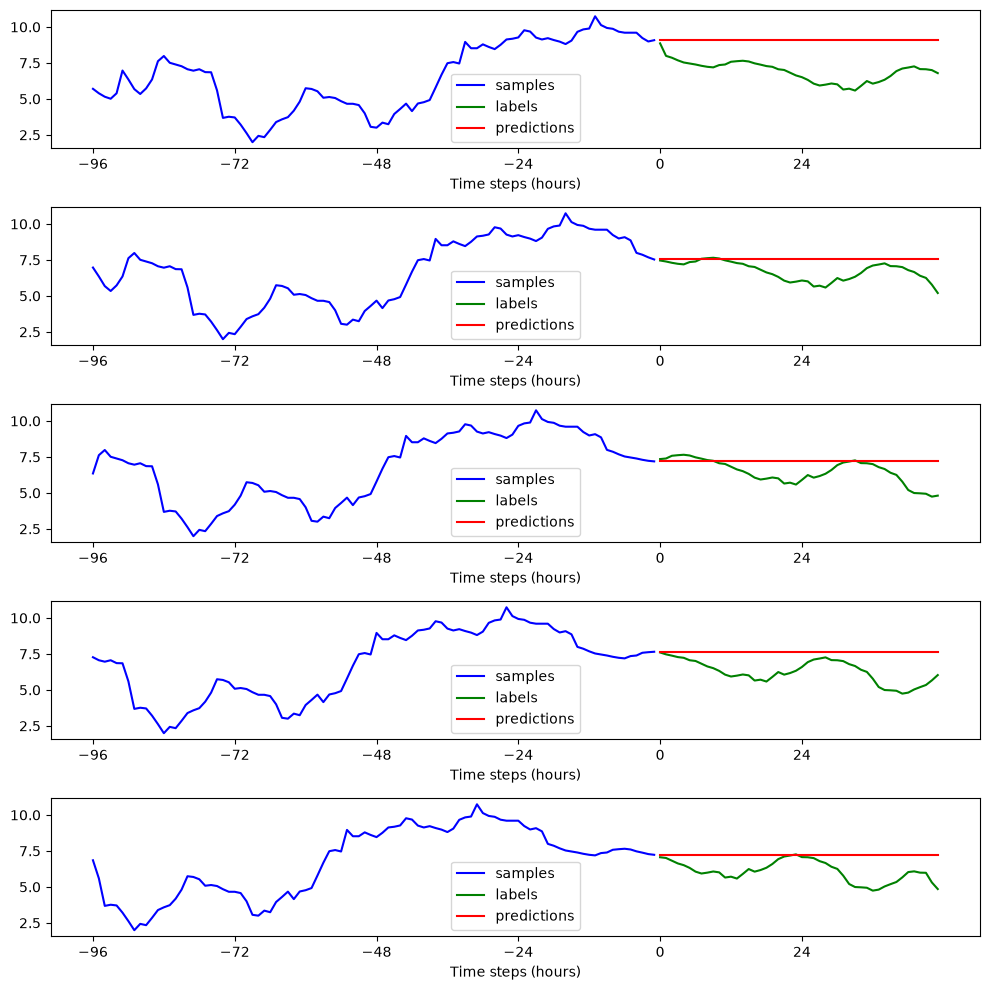

Baseline mean_baseline


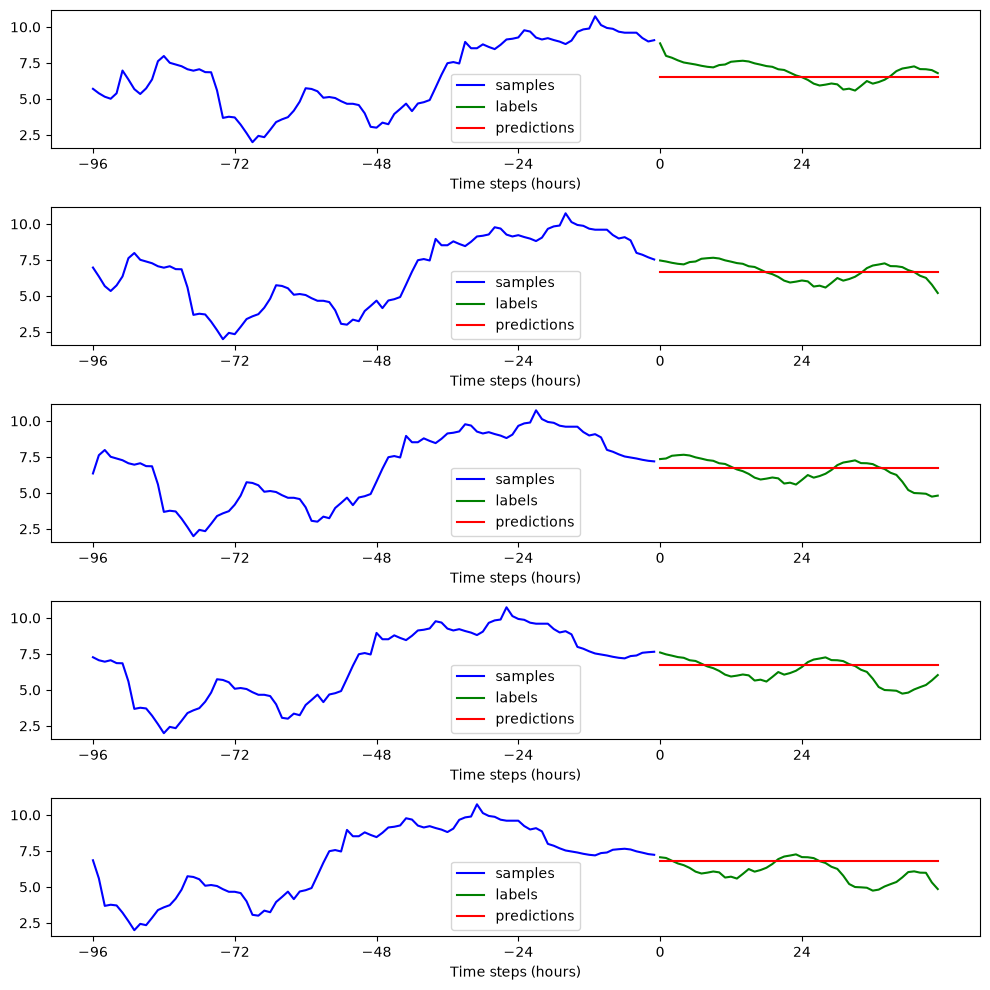

Baseline repeat_baseline


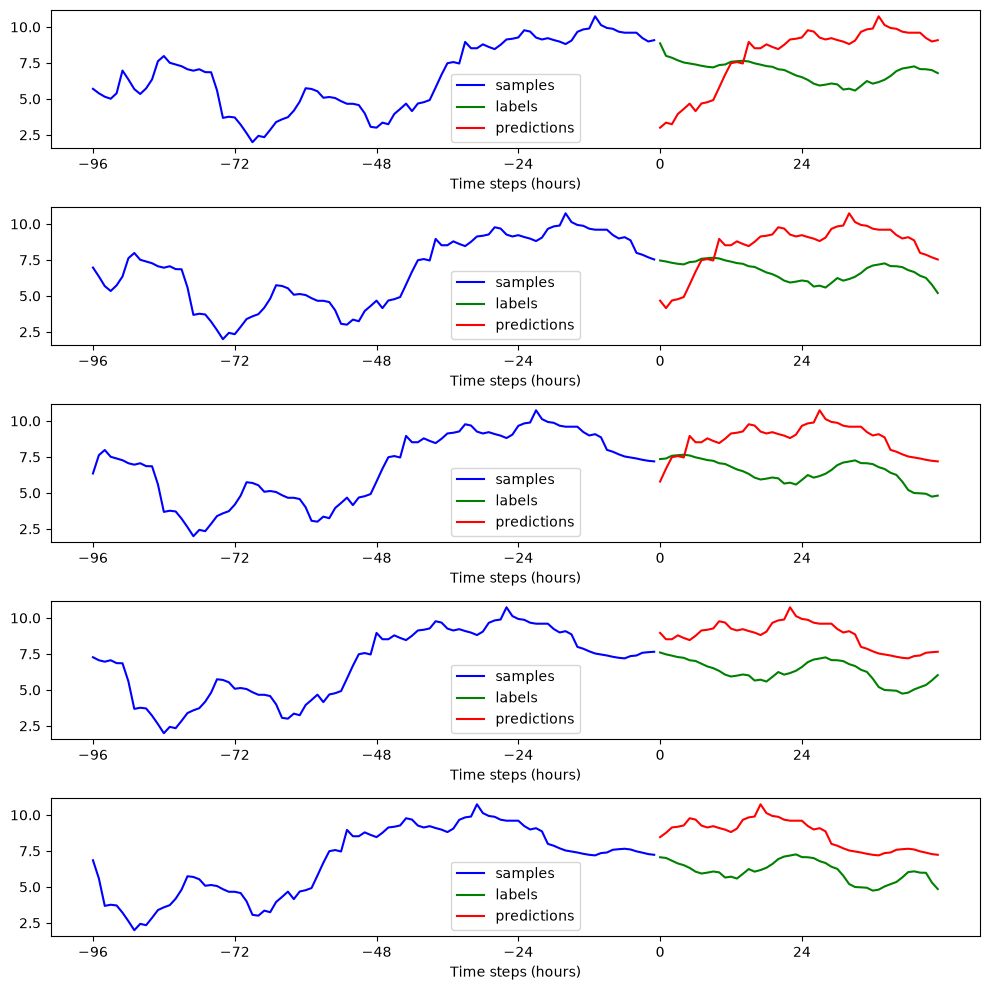

In [23]:
nb_samples_to_plot = 5

val_samples = scaler.inverse_transform_target(val_sample_windows[:, :, target_feature_id])
val_labels = scaler.inverse_transform_target(val_label_windows)

for name, baseline in baselines.items():
    predictions = baseline(val_sample_windows)
    print(f"Baseline {name}")

    predictions = scaler.inverse_transform_target(predictions)

    plot_window(val_samples, val_labels, predictions, nb_samples_to_plot)

<div class="alert alert-info">

The three baseline visualization correspond to what we were trying to do.

This plot also shows why the reapeat baseline may be better than the two others.

### IV.3 🤖 Machine learning: linear regression

The machine learning model we choose is the linear regression, we could try more complex models. However, for regressions, the linear regression is always good to try, and more complex models are explored below (gradient boosted trees, then an LSTM).

It has the advantage of not having hyperparameters to tune, and trains quickly. Hence we choose to stay with only one linear model for simplicity.

Linear regression MAE (unclipped): 2.324


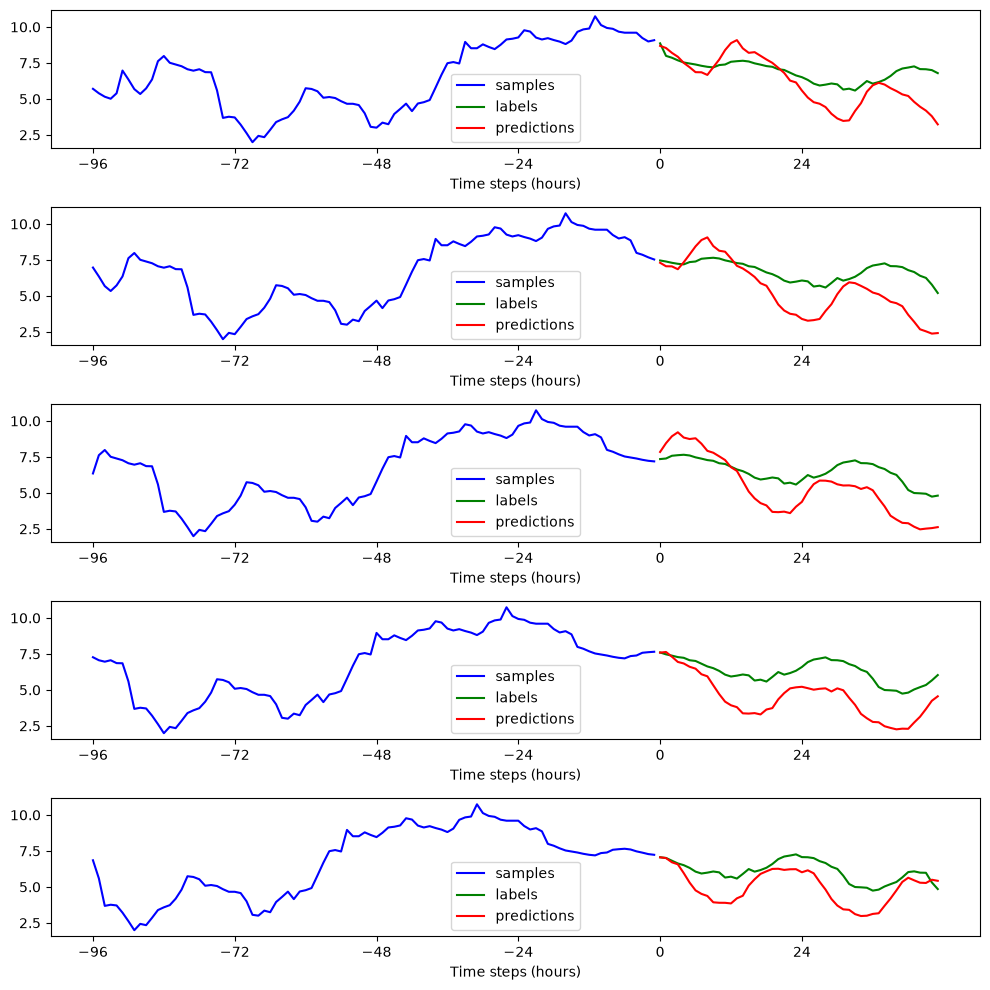

In [24]:
# train the linear regression
linear_model = LinearRegression()

train_samples_flattened = train_sample_windows.reshape((train_sample_windows.shape[0], -1))
val_samples_flattened = val_sample_windows.reshape((val_sample_windows.shape[0], -1))
test_samples_flattened = test_sample_windows.reshape((test_sample_windows.shape[0], -1))

linear_model.fit(train_samples_flattened, train_label_windows)

# evaluate the linear regression (unclipped, to see the raw effect of extreme predictions)
mae_unclipped = evaluate_model(linear_model.predict, val_samples_flattened, val_label_windows, scaler, clip=False)
print(f"Linear regression MAE (unclipped): {mae_unclipped:.3f}")

# plot the linear regression predictions
predictions = linear_model.predict(val_samples_flattened)
predictions = scaler.inverse_transform_target(predictions)
plot_window(val_samples, val_labels, predictions, nb_samples_to_plot)

<div class="alert alert-info">

The MAE value is really high while the plot shows quite pertinent predictions, at least compared to baselines. Therefore we expect a better MAE.

This could be explained if the linear model predicts extreme values for some samples. I would argue that it is because of unseen data out of the initial distribution. Therefore, we will clip values between the maximum and the minimum temperatures for evaluation, via `scaler.clip_to_target_range` / `evaluate_model(..., clip=True)`.

I choose to do it for evaluation because other models may suffer from this problem too, and `evaluate_model` applies the exact same post-processing to every model in this notebook (baselines, linear regression, LightGBM, and the LSTM), so the final comparison table stays apples-to-apples.

Linear regression MAE (clipped): 2.324


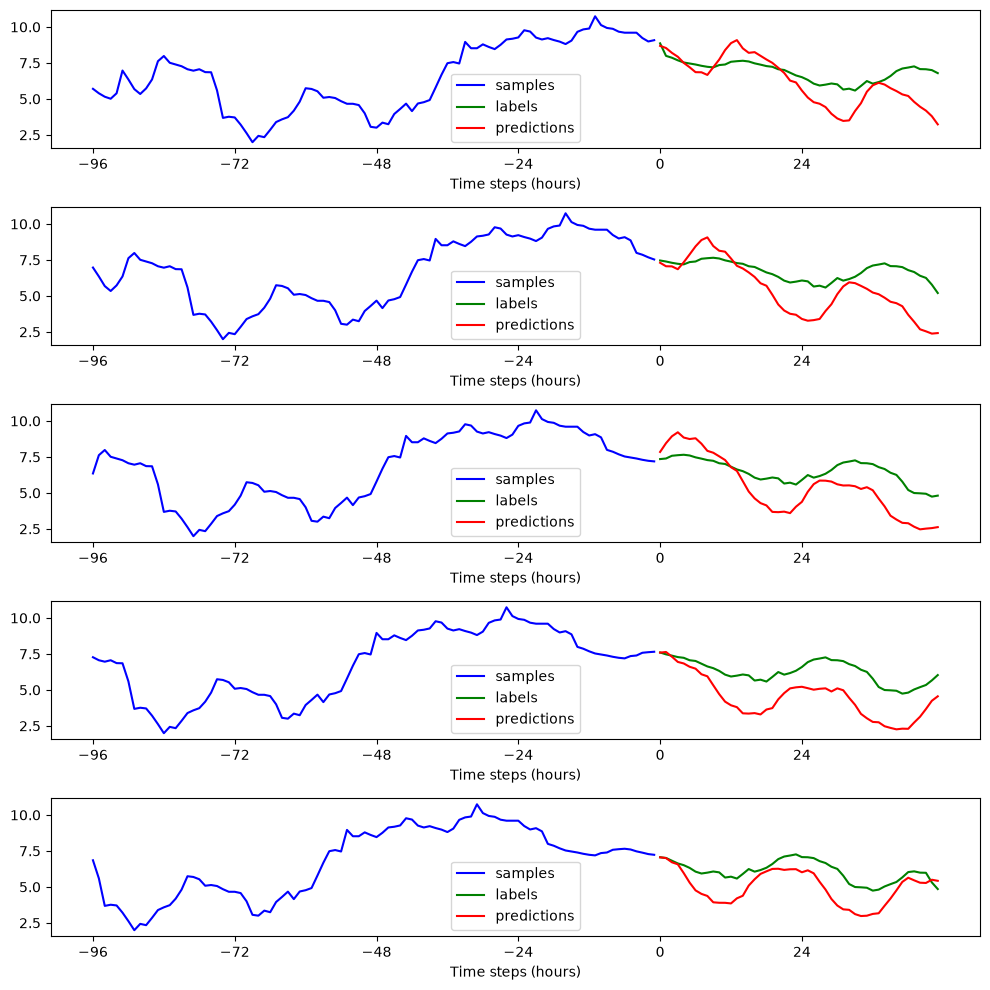

In [25]:
# evaluate the linear regression, this time clipped (the evaluate_model default)
mae = evaluate_model(linear_model.predict, val_samples_flattened, val_label_windows, scaler)
print(f"Linear regression MAE (clipped): {mae:.3f}")

# plot the linear regression predictions
predictions = linear_model.predict(val_samples_flattened)
predictions = scaler.clip_to_target_range(scaler.inverse_transform_target(predictions))
plot_window(val_samples, val_labels, predictions, nb_samples_to_plot)

<div class="alert alert-info">

Now the mean absolute error is much more coherent with the visualization.

### IV.4 🌳 Machine learning: gradient boosted trees (LightGBM)

Before reaching for a neural network, it's worth trying a stronger tabular baseline: gradient boosted trees on the same flattened window features used for the linear regression. Tree ensembles are a common strong (and cheap) baseline for short-horizon tabular forecasting, so this sets a more meaningful bar for what the LSTM actually needs to beat than the linear regression alone.

LightGBM's sklearn API is single-output, so we train one boosted model per forecast step (a "direct" multi-horizon strategy, as opposed to a recursive one that would feed each prediction back in as input for the next step). Direct models avoid compounding one-step errors, at the cost of not sharing information across horizons.

LightGBM MAE: 2.278


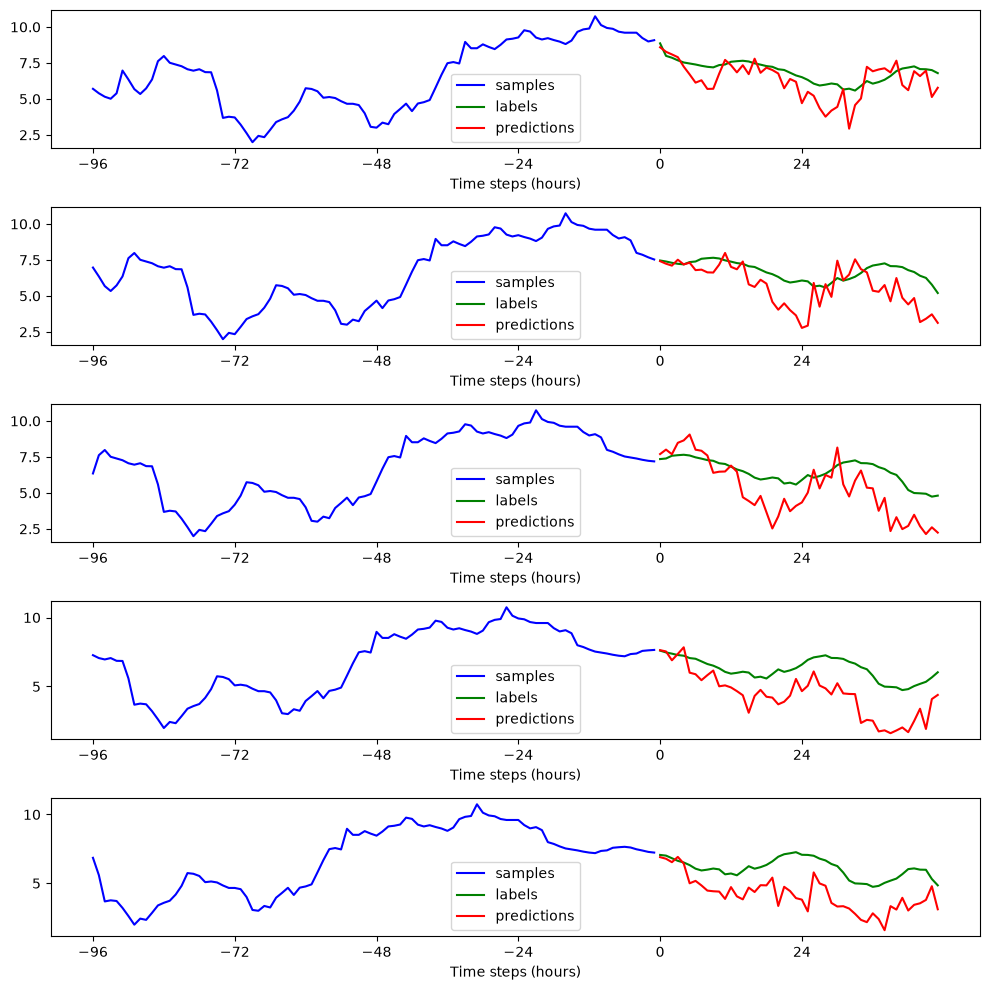

In [26]:
from sklearn.multioutput import MultiOutputRegressor

# NOTE: single-threaded (n_jobs=1) and MultiOutputRegressor run sequentially
# (no joblib n_jobs=-1) on purpose -- see the OpenMP note in the first cell.
# LightGBM's own multiprocessing/threading otherwise deadlocks against PyTorch
# later in this notebook.
lgbm_model = MultiOutputRegressor(
    lgb.LGBMRegressor(random_state=SEED, n_estimators=150, num_leaves=31, n_jobs=1, verbosity=-1),
)
lgbm_model.fit(train_samples_flattened, train_label_windows)

mae = evaluate_model(lgbm_model.predict, val_samples_flattened, val_label_windows, scaler)
print(f"LightGBM MAE: {mae:.3f}")

predictions = lgbm_model.predict(val_samples_flattened)
predictions = scaler.clip_to_target_range(scaler.inverse_transform_target(predictions))
plot_window(val_samples, val_labels, predictions, nb_samples_to_plot)

### IV.5 🧠 Deep learning: LSTM

The model we choose is based on LSTM neurons. This model have proven his efficiency on time series over the years, hence it is natural to try it. Compared to RNN, it is better with long time series, but is still simple compare to Bi-GRU or things like that.

#### a - Make dataloader

In [27]:
# create datasets
torch_train_dataset = TensorDataset(torch.FloatTensor(train_sample_windows),
                                    torch.FloatTensor(train_label_windows))
torch_val_dataset = TensorDataset(torch.FloatTensor(val_sample_windows),
                                  torch.FloatTensor(val_label_windows))
torch_test_dataset = TensorDataset(torch.FloatTensor(test_sample_windows),
                                   torch.FloatTensor(test_label_windows))

batch_size = 1024

# create dataloaders
train_loader = DataLoader(torch_train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(torch_val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(torch_test_dataset, batch_size=batch_size, shuffle=False)

#### b - Define LSTM model

In [28]:
# instanciate model (LSTMForecaster imported from src.models)
lstm_model = LSTMForecaster(input_size=train_sample_windows.shape[-1],
                            hidden_size=labels_window_size,  # arbitrary
                            num_layers=1,
                            output_size=labels_window_size)

#### c - Model training

An earlier version of this notebook trained for a hardcoded 20 epochs and found validation loss still improving at the cutoff -- i.e. the model was stopped before it actually converged, which made the LSTM look worse than it necessarily is. This version instead trains up to a generous epoch cap with early stopping (`patience` epochs with no validation-loss improvement greater than `min_delta`), and restores the best checkpoint, so the LSTM gets a fair shot at converging before we compare it to LightGBM/linear regression.

In [29]:
# train up to a generous cap; early stopping (via patience) decides the
# actual epoch count instead of us guessing one.
max_epochs = 200
patience = 10

history = train_lstm(lstm_model, train_loader, val_loader, num_epochs=max_epochs, lr=1e-3, patience=patience)

Epoch [1/200], Train Loss: 0.9803, Validation Loss: 0.8136


Epoch [2/200], Train Loss: 0.9193, Validation Loss: 0.7458


Epoch [3/200], Train Loss: 0.8296, Validation Loss: 0.6343


Epoch [4/200], Train Loss: 0.6876, Validation Loss: 0.4644


Epoch [5/200], Train Loss: 0.5147, Validation Loss: 0.3331


...

Epoch [68/200], Train Loss: 0.1135, Validation Loss: 0.1102


Epoch [69/200], Train Loss: 0.1132, Validation Loss: 0.1099


Epoch [70/200], Train Loss: 0.1128, Validation Loss: 0.1097


Epoch [71/200], Train Loss: 0.1124, Validation Loss: 0.1105


Epoch [72/200], Train Loss: 0.1121, Validation Loss: 0.1096
Early stopping at epoch 72 (no val improvement for 10 epochs)


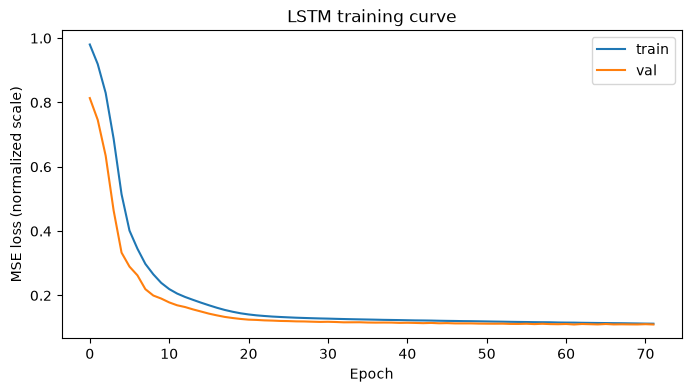

Ran 72 epochs (cap was 200); best validation loss at epoch 62.


In [30]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE loss (normalized scale)")
plt.title("LSTM training curve")
plt.legend()
plt.show()

nb_epochs_run = len(history["val_loss"])
best_epoch = int(np.argmin(history["val_loss"])) + 1
print(f"Ran {nb_epochs_run} epochs (cap was {max_epochs}); best validation loss at epoch {best_epoch}.")

<div class="alert alert-info">

Unlike the 20-epoch snapshot from the earlier draft, this run actually reaches a validation-loss plateau: it trained for 72 epochs before early stopping fired (10 epochs with no improvement greater than `min_delta`), with the best checkpoint at epoch 62 — restored automatically rather than whatever epoch happened to be last. That's the epoch count and the weights used for every LSTM evaluation below.

This matters for more than just process: it changes the outcome. The earlier, artificially-capped-at-20-epochs LSTM had a test MAE of 2.537°C, behind both LightGBM (2.365°C) and linear regression (2.450°C). Trained to an actual plateau, the LSTM's test MAE drops to 2.336°C — now *ahead* of LightGBM. The original "the LSTM did not win" conclusion was an artifact of under-training, not a genuine result about which model suits this problem better.

#### d - Evaluation

The evaluation of the LSTM on the validation dataset will decide which of the LSTM, linear regression, and LightGBM is the best model for our use case.

We evaluate it through the same `evaluate_model` function as every other model (rescale to degrees, then clip to the train-set range), for a fair comparison — the earlier version of this notebook skipped clipping for the LSTM specifically, which wasn't a fair comparison against the linear regression and LightGBM.

LSTM MAE: 2.237


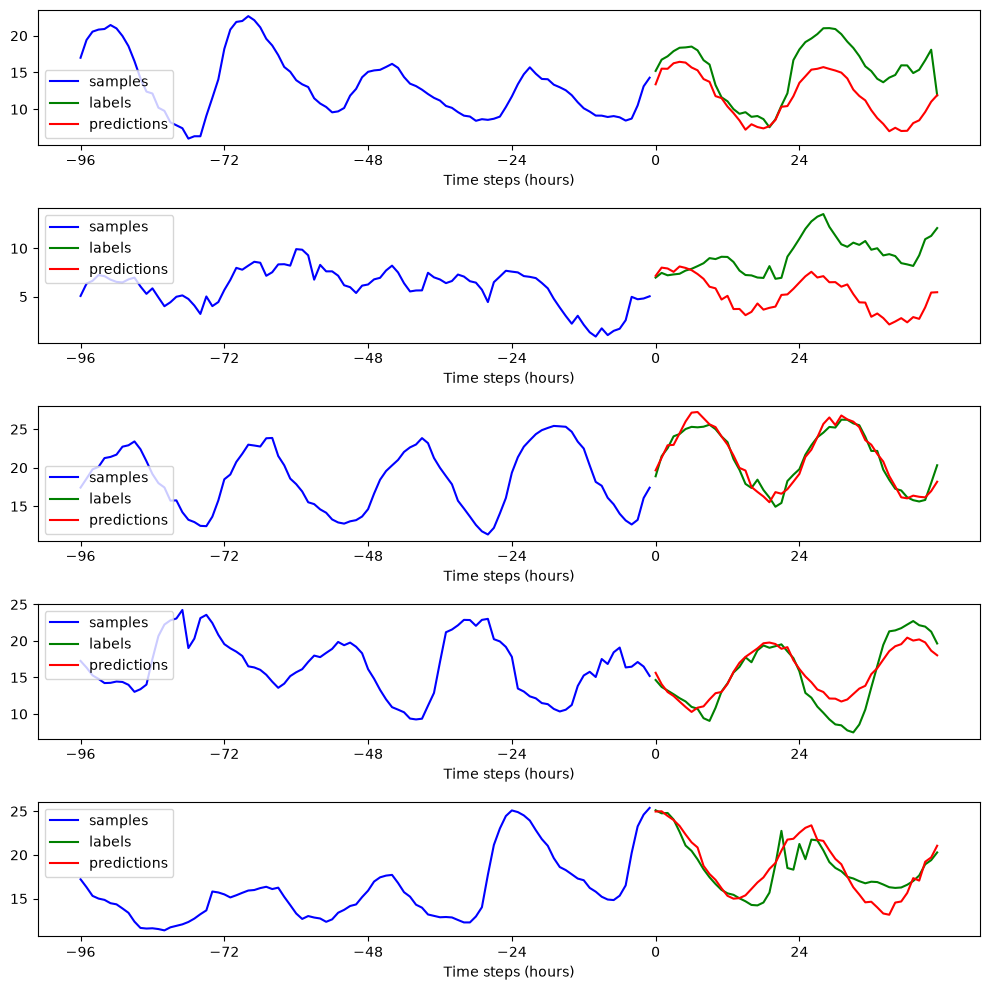

In [31]:
def lstm_predict(samples):
    lstm_model.eval()
    with torch.no_grad():
        return lstm_model(torch.FloatTensor(samples)).numpy()


mae = evaluate_model(lstm_predict, val_sample_windows, val_label_windows, scaler)
print(f"LSTM MAE: {mae:.3f}")

predictions = scaler.clip_to_target_range(scaler.inverse_transform_target(lstm_predict(val_sample_windows)))
plot_window(val_samples, val_labels, predictions, nb_samples_to_plot, random_samples=True)

To be sure our model will perform well and that we did not overfit our validation dataset, we now evaluate every model on the test set (2015-2016), which none of them (including the linear regression and LightGBM, whose hyperparameters were chosen ahead of time rather than tuned against it) has seen.

LSTM test MAE: 2.336


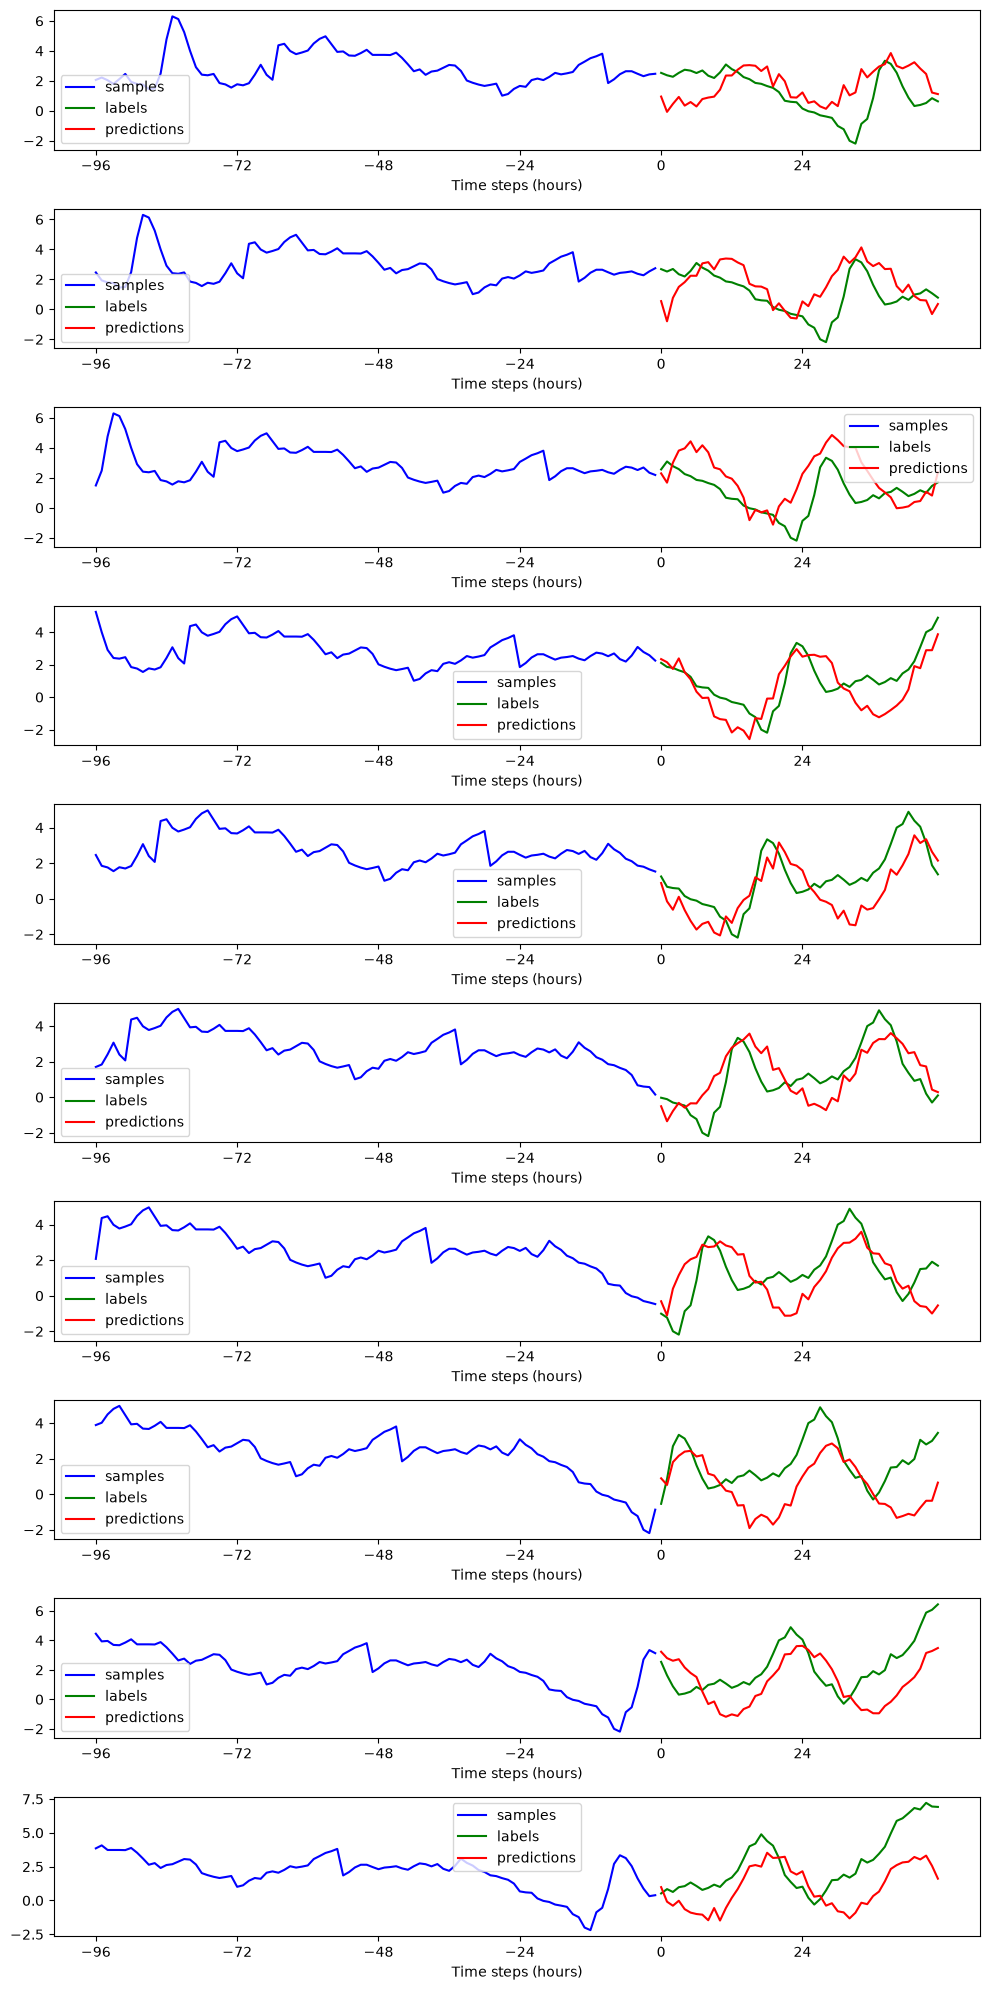

In [32]:
test_samples = scaler.inverse_transform_target(test_sample_windows[:, :, target_feature_id])
test_labels = scaler.inverse_transform_target(test_label_windows)

lstm_test_predictions = scaler.clip_to_target_range(scaler.inverse_transform_target(lstm_predict(test_sample_windows)))
lstm_test_mae = evaluate_model(lstm_predict, test_sample_windows, test_label_windows, scaler)
print(f"LSTM test MAE: {lstm_test_mae:.3f}")

plot_window(test_samples, test_labels, lstm_test_predictions, 10)

### IV.6 🔭 Error by forecast horizon

The LSTM's overall MAE hides how error is distributed across the 48-hour horizon. We'd expect predicting 1 hour ahead to be much easier than 48 hours ahead; let's check, and compare against the repeat baseline (our strongest non-learned baseline) on the same axis.

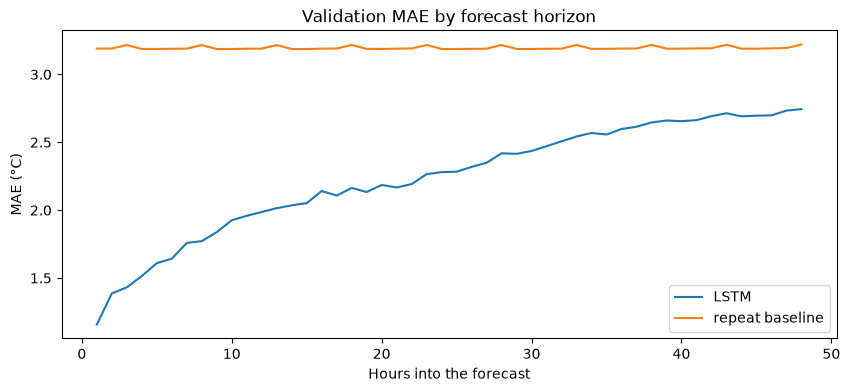

In [33]:
repeat_val_predictions = scaler.clip_to_target_range(
    scaler.inverse_transform_target(baselines["repeat_baseline"](val_sample_windows))
)
lstm_val_predictions = scaler.clip_to_target_range(scaler.inverse_transform_target(lstm_predict(val_sample_windows)))

horizon_hours = np.arange(1, labels_window_size + 1)
lstm_mae_by_horizon = mae_by_horizon(lstm_val_predictions, val_labels)
repeat_mae_by_horizon = mae_by_horizon(repeat_val_predictions, val_labels)

plt.figure(figsize=(10, 4))
plt.plot(horizon_hours, lstm_mae_by_horizon, label="LSTM")
plt.plot(horizon_hours, repeat_mae_by_horizon, label="repeat baseline")
plt.xlabel("Hours into the forecast")
plt.ylabel("MAE (°C)")
plt.title("Validation MAE by forecast horizon")
plt.legend()
plt.show()

<div class="alert alert-info">

MAE grows with the forecast horizon for both models, as expected — the 1-hour-ahead prediction is anchored much more tightly to the current temperature than the 48-hour-ahead one. This directly explains the "big mistakes just one hour in the future" observation from the original draft: it wasn't happening at the 1-hour mark specifically, it's the tail of the horizon (approaching 48h) that dominates the average MAE. Framing the error this way is also a more honest way to report a multi-step forecaster than a single averaged number.

## V 📊 Final model comparison

All models scored through the same `evaluate_model` (rescaled to degrees, clipped to the train range) on both validation and test, so this table is the actual basis for picking a "best" model rather than a single cherry-picked number.

In [34]:
results = []
for name, baseline in baselines.items():
    results.append({
        "model": name,
        "val_mae": evaluate_model(baseline, val_sample_windows, val_label_windows, scaler),
        "test_mae": evaluate_model(baseline, test_sample_windows, test_label_windows, scaler),
    })

results.append({
    "model": "linear_regression",
    "val_mae": evaluate_model(linear_model.predict, val_samples_flattened, val_label_windows, scaler),
    "test_mae": evaluate_model(linear_model.predict, test_samples_flattened, test_label_windows, scaler),
})

results.append({
    "model": "lightgbm",
    "val_mae": evaluate_model(lgbm_model.predict, val_samples_flattened, val_label_windows, scaler),
    "test_mae": evaluate_model(lgbm_model.predict, test_samples_flattened, test_label_windows, scaler),
})

results.append({
    "model": "lstm",
    "val_mae": evaluate_model(lstm_predict, val_sample_windows, val_label_windows, scaler),
    "test_mae": evaluate_model(lstm_predict, test_sample_windows, test_label_windows, scaler),
})

results_table = pd.DataFrame(results).set_index("model").sort_values("test_mae")
results_table.round(3)

,val_mae,test_mae
model,,
lstm,2.237,2.336
lightgbm,2.278,2.365
linear_regression,2.324,2.450
repeat_baseline,3.195,3.478
mean_baseline,3.520,3.742
last_step_baseline,3.527,3.797


## Conclusions

To summarize, the task was the predictions of the temperatures for the next 48 hours with weather data. The constraint was that the model only had access to few days of previous data.

Therefore, we:
- selected a subset of pertinent variables, and checked whether doing so on the full dataset instead of the train split leaked anything — it did, in a narrow, threshold-boundary way (section III.1), which is a useful reminder to fit that kind of decision on train data going forward
- explored the dataset seasonalities and trends
- divided the dataset and applied windowing, with normalization statistics fit on the train split only
- designed three naive baselines
- trained and evaluated a linear regression, a LightGBM model, and an LSTM trained to convergence via early stopping, all scored through the same pipeline
- looked at how error grows across the 48-hour forecast horizon, not just the averaged MAE

**With the LSTM actually trained to convergence (72 epochs, best checkpoint at epoch 62, section IV.5), it comes out on top**: test MAE of 2.336°C, versus 2.365°C for LightGBM and 2.450°C for linear regression. All three comfortably beat the naive baselines (3.48-3.80°C on test). This reverses what an earlier, capped-at-20-epochs version of this notebook concluded ("the LSTM did not win") — that conclusion was an artifact of stopping training before validation loss had plateaued, not a real finding about the task. The lesson generalizes past this one model: a model that looks worse than a simpler baseline is only informative once you've checked it was actually given a fair chance to converge.

The margin between the top three models is still fairly narrow (2.34-2.45°C), and all of them only improve on the repeat baseline (3.48°C) by about 1-1.1°C of MAE. Before deploying any of these, the honest next questions are whether that improvement is worth the LSTM's added training/inference cost over LightGBM or a linear model for the intended use case, and whether the error-by-horizon curve (section IV.6) is acceptable for that use case's tolerance at the far end of the 48-hour window.

Further directions:
- Tune the LSTM's other hyperparameters (hidden size, depth, learning rate) instead of the current arbitrary choice, and/or try a Bi-GRU or a small Transformer.
- Try a recursive (autoregressive) strategy instead of direct multi-horizon prediction, and compare error accumulation against the direct LightGBM/LSTM.
- Add prediction intervals (e.g. quantile LightGBM, or MC dropout for the LSTM) instead of only point forecasts.